In [38]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import joblib

In [39]:

# Load cleaned dataset
train_df = pd.read_csv("/content/data/clean_train.csv")
val_df   = pd.read_csv("/content/data/clean_val.csv")



In [40]:
# Tokenization
VOCAB_SIZE = 10000
MAX_LEN = 100
EMBED_DIM = 100

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['tweet_content'])

In [41]:
X_train = pad_sequences(tokenizer.texts_to_sequences(train_df['tweet_content']), maxlen=MAX_LEN)
X_val   = pad_sequences(tokenizer.texts_to_sequences(val_df['tweet_content']), maxlen=MAX_LEN)

y_train = to_categorical(train_df['label'], num_classes=3)
y_val   = to_categorical(val_df['label'], num_classes=3)

In [42]:
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))

with open("/content/data/glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        index = tokenizer.word_index.get(word)
        if index and index < VOCAB_SIZE:
            embedding_matrix[index] = vector

In [43]:
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [44]:

# Simple RNN
rnn_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=True),

    SimpleRNN(64),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

rnn_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


934/934 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.5487 - loss: 0.9523 - val_accuracy: 0.6784 - val_loss: 0.7529
Epoch 2/10
934/934 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6880 - loss: 0.7385 - val_accuracy: 0.7896 - val_loss: 0.5539
Epoch 3/10
934/934 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7673 - loss: 0.5854 - val_accuracy: 0.8440 - val_loss: 0.4102
Epoch 4/10
934/934 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8258 - loss: 0.4610 - val_accuracy: 0.8900 - val_loss: 0.3143
Epoch 5/10
934/934 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8620 - loss: 0.3735 - val_accuracy: 0.9190 - val_loss: 0.2553
Epoch 6/10
934/934 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8852 - loss: 0.3142 - val_accuracy: 0.9323 - val_loss: 0.2260
Epoch 7/10
934/934 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9032 - loss: 0.2687 - val_accuracy: 0.9323 - val_loss: 0.2164
Epoch 8/10
934/934 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9143 - loss: 0.2347 - val_accuracy: 0.9335 - v

In [45]:
# Bidirectional LSTM
bilstm_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=True),

    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),

    Bidirectional(LSTM(64)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(3, activation='softmax')
])


bilstm_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


bilstm_history = bilstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/10
934/934 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.6587 - loss: 0.7939 - val_accuracy: 0.7727 - val_loss: 0.5703
Epoch 2/10
934/934 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.7853 - loss: 0.5439 - val_accuracy: 0.8815 - val_loss: 0.3451
Epoch 3/10
934/934 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.8588 - loss: 0.3758 - val_accuracy: 0.9045 - val_loss: 0.2572
Epoch 4/10
934/934 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.8974 - loss: 0.2769 - val_accuracy: 0.9335 - val_loss: 0.2101
Epoch 5/10
934/934 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.9214 - loss: 0.2148 - val_accuracy: 0.9395 - val_loss: 0.2114


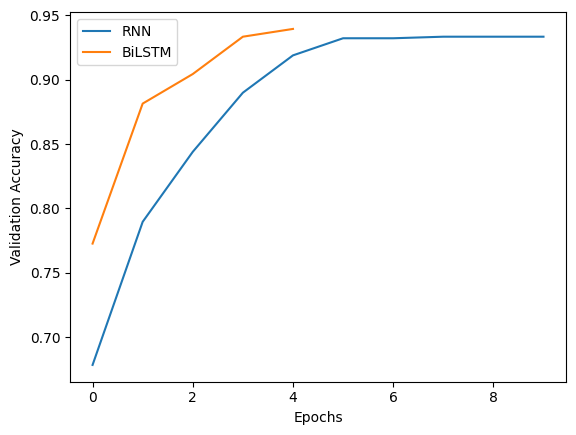

In [46]:

# Plot validation accuracy
plt.plot(rnn_history.history['val_accuracy'], label='RNN')
plt.plot(bilstm_history.history['val_accuracy'], label='BiLSTM')
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()


In [48]:

# Save models
rnn_model.save("/content/models/rnn_model.h5")
bilstm_model.save("/content/models/lstm_model.h5")
joblib.dump(tokenizer, "/content/models/tokenizer.pkl")

['/content/models/tokenizer.pkl']